Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Pandas Version:", pd.__version__)

Pandas Version: 2.3.3


TASK 1 – Explore the Dataset

In [2]:
df = pd.read_csv("students.csv")

print("=" * 60)
print("TASK 1 : DATASET EXPLORATION")
print("=" * 60)

print("\nFirst 5 Records")
print(df.head())

print("\nLast 5 Records")
print(df.tail())

print("\nShape")
print(df.shape)

print("\nRows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe(include="all"))

TASK 1 : DATASET EXPLORATION

First 5 Records
      Name Department  Age  Marks  Attendance Gender        City      Year  \
0     Arun        CSE   20     85          90      M     Chennai  2nd Year   
1    Priya         IT   21     92          95      F  Coimbatore  3rd Year   
2  Karthik        CSE   20     76          80      M     Madurai  2nd Year   
3    Meena        ECE   22     88          94      F      Trichy  3rd Year   
4    Rahul         IT   19     67          75      M       Salem  2nd Year   

   CGPA  Backlogs  
0   8.2         0  
1   9.1         0  
2   7.4         1  
3   8.6         0  
4   6.8         2  

Last 5 Records
       Name Department  Age  Marks  Attendance Gender        City      Year  \
15  Lakshmi        ECE   21     82          86      F     Vellore  3rd Year   
16     Ajay        CSE   19     75          81      M     Madurai  2nd Year   
17   Nithya         IT   20     88          91      F     Chennai  2nd Year   
18   Vishal      AI/DS   22     9

Requirements Covered

Read CSV
head()
tail()
shape
columns
info()

Extra

dtypes
missing values
statistical summary

TASK 2 – Answer Questions

In [3]:
print("=" * 60)
print("TASK 2 : CLASS PERFORMANCE REPORT")
print("=" * 60)

top_student = df.loc[df["Marks"].idxmax()]
best_attendance = df.loc[df["Attendance"].idxmax()]

print(f"Highest Marks Student : {top_student['Name']}")
print(f"Marks                 : {top_student['Marks']}")

print()

print(f"Average CGPA          : {df['CGPA'].mean():.2f}")

print()

print(f"Best Attendance       : {best_attendance['Name']}")
print(f"Attendance            : {best_attendance['Attendance']}%")

print()

print(f"Average Attendance    : {df['Attendance'].mean():.2f}%")

TASK 2 : CLASS PERFORMANCE REPORT
Highest Marks Student : Vishal
Marks                 : 96

Average CGPA          : 8.15

Best Attendance       : Vishal
Attendance            : 99%

Average Attendance    : 88.15%


Extra Visualization

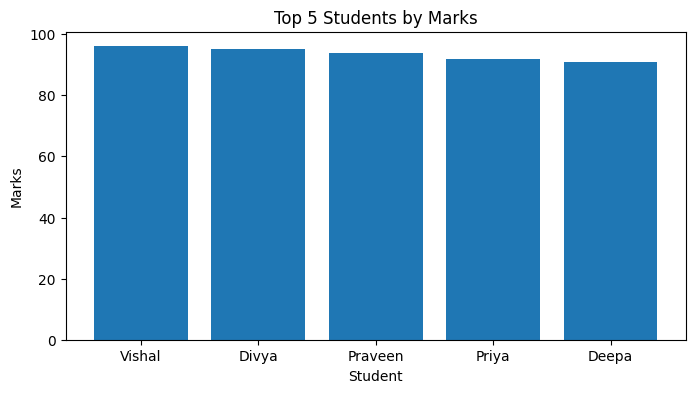

In [4]:
top5 = df.nlargest(5, "Marks")

plt.figure(figsize=(8,4))
plt.bar(top5["Name"], top5["Marks"])

plt.title("Top 5 Students by Marks")
plt.xlabel("Student")
plt.ylabel("Marks")

plt.show()

TASK 3 – Filtering

1. Marks >80 and No Backlogs

In [5]:
print("=" * 60)
print("TASK 3 : FILTERING STUDENTS")
print("=" * 60)

high_marks = df[
    (df["Marks"] > 80) &
    (df["Backlogs"] == 0)
]

print("\nStudents with Marks >80 and No Backlogs\n")
print(high_marks[["Name","Department","Marks","CGPA"]])

TASK 3 : FILTERING STUDENTS

Students with Marks >80 and No Backlogs

       Name Department  Marks  CGPA
0      Arun        CSE     85   8.2
1     Priya         IT     92   9.1
3     Meena        ECE     88   8.6
5     Divya        CSE     95   9.4
8   Vignesh        CSE     90   8.8
9    Anitha         IT     85   8.3
11    Deepa        ECE     91   9.0
13    Sneha         IT     87   8.5
14  Praveen      AI/DS     94   9.2
15  Lakshmi        ECE     82   8.0
17   Nithya         IT     88   8.4
18   Vishal      AI/DS     96   9.5


2. CSE + 3rd Year

In [6]:
cse_students = df[
    (df["Department"] == "CSE") &
    (df["Year"] == "3rd Year")
]

print("\nCSE Students in 3rd Year\n")
print(cse_students)


CSE Students in 3rd Year

    Name Department  Age  Marks  Attendance Gender     City      Year  CGPA  \
5  Divya        CSE   21     95          98      F  Chennai  3rd Year   9.4   

   Backlogs  
5         0  


3. CGPA Above Average

In [7]:
average_cgpa = df["CGPA"].mean()

above_average = df[df["CGPA"] > average_cgpa]

print("\nStudents Above Average CGPA\n")
print(above_average[["Name","CGPA"]])


Students Above Average CGPA

       Name  CGPA
0      Arun   8.2
1     Priya   9.1
3     Meena   8.6
5     Divya   9.4
8   Vignesh   8.8
9    Anitha   8.3
11    Deepa   9.0
13    Sneha   8.5
14  Praveen   9.2
17   Nithya   8.4
18   Vishal   9.5


TASK 4 – Data Cleaning

In [8]:
dirty_df = pd.read_csv("dirty_students.csv")

print("=" * 60)
print("TASK 4 : DATA CLEANING")
print("=" * 60)

print("\nDataset Shape Before Cleaning")
print(dirty_df.shape)

print("\nMissing Values")
print(dirty_df.isnull().sum())

print("\nDuplicate Rows")
print(dirty_df.duplicated().sum())

TASK 4 : DATA CLEANING

Dataset Shape Before Cleaning
(23, 10)

Missing Values
Name          0
Department    1
Age           1
Marks         1
Attendance    1
Gender        0
City          1
Year          0
CGPA          1
Backlogs      0
dtype: int64

Duplicate Rows
3


Filling Missing Values

In [9]:
dirty_df["Age"] = dirty_df["Age"].fillna(dirty_df["Age"].mean())

dirty_df["Marks"] = dirty_df["Marks"].fillna(dirty_df["Marks"].mean())

dirty_df["Attendance"] = dirty_df["Attendance"].fillna(dirty_df["Attendance"].mean())

dirty_df["CGPA"] = dirty_df["CGPA"].fillna(dirty_df["CGPA"].mean())

dirty_df["Department"] = dirty_df["Department"].fillna("Unknown")

dirty_df["City"] = dirty_df["City"].fillna("Unknown")

Remove Duplicates

In [10]:
dirty_df = dirty_df.drop_duplicates()

dirty_df = dirty_df.reset_index(drop=True)

Verify

In [11]:
print("\nCleaning Completed")

print("\nRemaining Missing Values")
print(dirty_df.isnull().sum())

print("\nFinal Shape")
print(dirty_df.shape)

dirty_df.to_csv("cleaned_students.csv", index=False)

print("\ncleaned_students.csv saved successfully.")


Cleaning Completed

Remaining Missing Values
Name          0
Department    0
Age           0
Marks         0
Attendance    0
Gender        0
City          0
Year          0
CGPA          0
Backlogs      0
dtype: int64

Final Shape
(20, 10)

cleaned_students.csv saved successfully.


TASK 5 – Scholarship Report

In [12]:
clean_df = pd.read_csv("cleaned_students.csv")

eligible = clean_df[
    (clean_df["CGPA"] >= 8.5) &
    (clean_df["Backlogs"] == 0) &
    (clean_df["Attendance"] >= 90)
]

Ranking students

In [13]:
eligible = eligible.sort_values(
    by=["CGPA","Marks"],
    ascending=False
)

eligible.insert(
    0,
    "Rank",
    range(1, len(eligible)+1)
)

Print Report

In [14]:
print("=" * 60)
print("MERIT SCHOLARSHIP REPORT")
print("=" * 60)

print(f"\nEligible Students : {len(eligible)}")

print("\nEligible Student List\n")

print(
    eligible[
        ["Rank","Name","Department","CGPA","Marks","Attendance"]
    ]
)

print("\nDepartment Distribution")

print(eligible["Department"].value_counts())

print()

print("Average Marks of Eligible Students :",
      round(eligible["Marks"].mean(),2))

print("Average Marks of Whole Class :",
      round(clean_df["Marks"].mean(),2))

MERIT SCHOLARSHIP REPORT

Eligible Students : 8

Eligible Student List

    Rank     Name Department  CGPA  Marks  Attendance
18     1   Vishal      AI/DS   9.5   96.0        99.0
5      2    Divya        CSE   9.4   95.0        98.0
14     3  Praveen      AI/DS   9.2   94.0        97.0
1      4    Priya         IT   9.1   92.0        95.0
11     5    Deepa        ECE   9.0   91.0        96.0
8      6  Vignesh        CSE   8.8   90.0        92.0
3      7    Meena        ECE   8.6   88.0        94.0
13     8    Sneha         IT   8.5   87.0        90.0

Department Distribution
Department
AI/DS    2
CSE      2
IT       2
ECE      2
Name: count, dtype: int64

Average Marks of Eligible Students : 91.62
Average Marks of Whole Class : 84.0


Save CSV

In [15]:
eligible.to_csv(
    "scholarship_shortlist.csv",
    index=False
)

print("\nScholarship shortlist saved successfully.")


Scholarship shortlist saved successfully.


Final Summary

In [16]:
print("=" * 60)
print("DAY 6 SUMMARY")
print("=" * 60)

print("✔ students.csv loaded successfully")
print("✔ Dataset explored")
print("✔ Performance analysis completed")
print("✔ Student filtering completed")
print("✔ Dataset cleaned")
print("✔ cleaned_students.csv created")
print("✔ Scholarship report generated")
print("✔ scholarship_shortlist.csv exported")

DAY 6 SUMMARY
✔ students.csv loaded successfully
✔ Dataset explored
✔ Performance analysis completed
✔ Student filtering completed
✔ Dataset cleaned
✔ cleaned_students.csv created
✔ Scholarship report generated
✔ scholarship_shortlist.csv exported
